In [47]:
import os, sys
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import json 
def find_root_path(path:str, word:str):
    parts = path.split(word, 1)    
    return parts[0] + word if len(parts) > 1 else path 
try:
    current_path = os.path.abspath(__file__)
except NameError:
    current_path = os.getcwd()
    
root_folder = find_root_path(os.path.abspath(current_path), 'art_lang')
sys.path.append(root_folder)
from rpod.optimization.parameters import dim_koz, COMMAND_LIST, n_time, tvec_sec, oec, period
from rpod.dynamics.dynamics_trans import propagate_ct, roe_to_rtn, cim_roe
from rpod.optimization.utils import * 
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
model_name = 'v08_w3_unseen_orin_r'
model_path = root_folder + f'/rpod/optimization/saved_files/warmstarting/ws_analysis_{model_name}.npz'  
ws_data = np.load(model_path, allow_pickle=True)
N_behavior = 6

In [49]:
# things needed for the post-SCP plots 
behav = ws_data['behavior']
J_cvx      = ws_data['J_cvx'] * 1e3
J_art      = ws_data['J_DT']* 1e3
J_cvx_scp  = ws_data['J_scp_cvx']* 1e3
J_art_scp  = ws_data['J_scp_DT']* 1e3
J_art_scp_r = ws_data['J_scp_DT_r']* 1e3
iter_cvx   = ws_data['iter_scp_cvx']
iter_art   = ws_data['iter_scp_DT']
iter_art_r = ws_data['iter_scp_DT_r']
ctgs0_cvx  = ws_data['ctgs0_cvx']
ctgs0_art  = ws_data['ctgs0_DT']
i_infeas_cvx     = ws_data['i_infeas_cvx']
i_infeas_cvx_scp = ws_data['i_infeas_scp_cvx']
i_infeas_art_scp = ws_data['i_infeas_scp_DT']
i_infeas_art_scp_r = ws_data['i_infeas_scp_DT_r']
runtime_cvx      = ws_data['runtime_cvx']
runtime_cvx_scp  = ws_data['runtime_scp_cvx'] + ws_data['runtime_cvx']
runtime_DT       = ws_data['runtime_DT']
runtime_DT_scp   = ws_data['runtime_scp_DT'] + ws_data['runtime_DT']
runtime_DT_scp_r = ws_data['runtime_scp_DT_r'] + ws_data['runtime_DT']

Behavior 0: 163 samples, safe ratio: ART=0.258, CVX=0.000
Behavior 1: 180 samples, safe ratio: ART=0.144, CVX=0.011
Behavior 2: 134 samples, safe ratio: ART=0.172, CVX=0.000
Behavior 3: 227 samples, safe ratio: ART=0.203, CVX=0.013
Behavior 4: 151 samples, safe ratio: ART=0.066, CVX=0.000
Behavior 5: 145 samples, safe ratio: ART=0.103, CVX=0.000


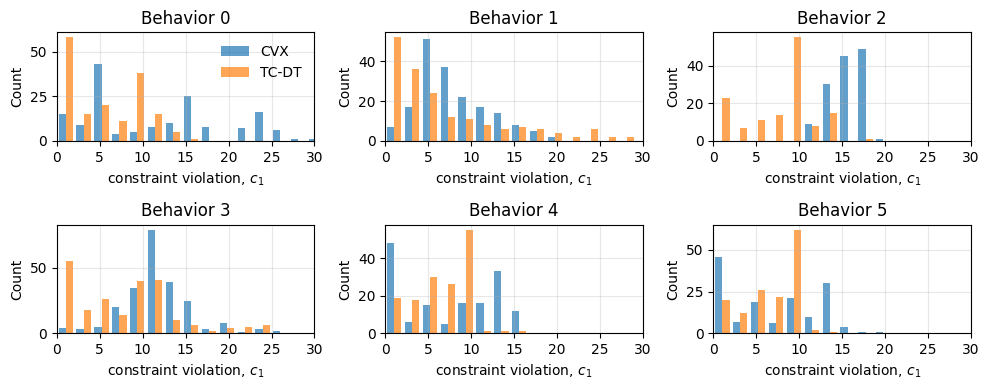

In [50]:
# check the CTG 

fig = plt.figure(figsize=(10, 4))
bins = np.linspace(0, n_time, int(n_time/2)) # constraint violation bins
bin_centers = 0.5 * (bins[:-1] + bins[1:])
width = (bins[1] - bins[0]) * 0.4  # each pillar width

for i in range(N_behavior):
    ctgs0_art_i = ctgs0_art[behav == i]
    ctgs0_cvx_i = ctgs0_cvx[behav == i]

    hist_DT, _ = np.histogram(ctgs0_art_i, bins=bins)
    hist_cvx, _ = np.histogram(ctgs0_cvx_i, bins=bins)
    
    ax_i = fig.add_subplot(2, 3, i + 1)
    ax_i.bar(bin_centers - width/2, hist_cvx, width=width, label="CVX", alpha=0.7)
    ax_i.bar(bin_centers + width/2, hist_DT, width=width, label="TC-DT", alpha=0.7)
    
    ax_i.set_xlabel("constraint violation, $c_1$")
    ax_i.set_ylabel("Count")
    ax_i.set_title(f"Behavior {i}")
    ax_i.grid(True, alpha=0.3)
    if i == 0:
        ax_i.legend(frameon=False)

    ax_i.set_xlim([0, 30])
    # ax_i.set_ylim([0, 75])

    print(f"Behavior {i}: {np.sum(behav==i)} samples, safe ratio: ART={np.sum(ctgs0_art_i==0)/len(ctgs0_art_i):.3f}, CVX={np.sum(ctgs0_cvx_i==0)/len(ctgs0_cvx_i):.3f}")

fig.tight_layout()
plt.show()

fig.savefig("figures/ws_analysis_ctg_hist.png", dpi=600)


In [51]:
def to_mask(idx, N):
    """Safe boolean mask from index list/array/None."""
    m = np.zeros(N, dtype=bool)
    if idx is None:
        return m
    arr = np.asarray(idx).ravel()
    if arr.size:
        arr = arr.astype(int)
        arr = arr[(arr >= 0) & (arr < N)]
        m[arr] = True
    return m


def make_bins(ctgs0, ctg_min=1, ctg_max=45, step=5):
    """
    Build final bin ids with a virtual '0' bin for ctg==0.

    Returns
    -------
    bin_ids_final : (N,) int in [0..n_bins-1]
    labels_full   : list[str] of length n_bins
    edges_core    : 1D array of float, len = n_bins (without the PS bin)
    """
    n = int((ctg_max - ctg_min + 1) / step)  # e.g. (45-1+1)/5 = 9
    edges_core = np.linspace(ctg_min, ctg_max, num=n + 1)
    bin_ids_core = np.clip(
        np.digitize(ctgs0, edges_core, right=False) - 1,
        0,
        len(edges_core) - 2,
    )

    bin_ids_final = bin_ids_core + 1   # shift for PS bin at 0
    ps_mask = np.isclose(ctgs0, 0.0)
    bin_ids_final[ps_mask] = 0

    labels_core = [
        f"{int(edges_core[i])}-{int(edges_core[i + 1])}"
        for i in range(len(edges_core) - 1)
    ]
    labels_full = ["0"] + labels_core
    return bin_ids_final, labels_full, edges_core


def counts_by_bin(mask, bin_ids, n_bins):
    """Count True entries of mask per bin id."""
    if not np.any(mask):
        return np.zeros(n_bins, dtype=int)
    return np.bincount(bin_ids[mask], minlength=n_bins).astype(int)


def half_violin(ax, data_list, positions, width, side, color, alpha, mean="center"):
    """Draw (half-)violins with mean ticks on given axis."""
    if not data_list:
        return

    v = ax.violinplot(
        data_list,
        positions=positions,
        widths=width,
        showmeans=False,
        showextrema=False,
    )

    for body, p in zip(v["bodies"], positions):
        verts = body.get_paths()[0].vertices
        if side == "left":
            verts[verts[:, 0] > p, 0] = p
        elif side == "right":
            verts[verts[:, 0] < p, 0] = p
        body.set_facecolor(color)
        body.set_alpha(alpha)
        body.set_edgecolor("none")

    # mean ticks
    for d, p in zip(data_list, positions):
        if len(d) == 0:
            continue
        m = float(np.mean(d))
        if mean == "left":
            ax.plot([p - 0.15, p - 0.02], [m, m], lw=2, color=color)
        elif mean == "right":
            ax.plot([p + 0.02, p + 0.15], [m, m], lw=2, color=color)
        else:
            ax.plot([p - 0.12, p + 0.12], [m, m], lw=2, color=color)


def prune_empty(datasets, positions):
    """Drop empty datasets while keeping positions aligned."""
    data_ok, pos_ok = [], []
    for d, p in zip(datasets, positions):
        arr = np.asarray(d).ravel()
        if arr.size:
            data_ok.append(arr.astype(float))
            pos_ok.append(p)
    return data_ok, pos_ok


def per_bin_arrays(values, ctgs0, edges_core, keep_idx_set):
    """Split `values` into lists of arrays per [edges_core] bin."""
    values = np.asarray(values)
    out = []
    for i in range(len(edges_core) - 1):
        lo, hi = edges_core[i], edges_core[i + 1]
        idx = np.where((ctgs0 >= lo) & (ctgs0 < hi))[0]
        if keep_idx_set is not None:
            idx = [j for j in idx if j in keep_idx_set]
        out.append(values[idx].astype(float).ravel())
    return out


def plot_metric_half_violins(
    ax,
    bin_ids,
    n_bins,
    m_domain,
    mask,
    vals_left,
    vals_right,
    color_left,
    color_right,
    alpha_left,
    alpha_right,
):
    """Helper for panels (3) and (4): two-sided half violins per non-PS bin."""
    data_left, data_right, pos_left, pos_right = [], [], [], []
    for b in range(1, n_bins):  # skip PS bin 0
        in_bin = (bin_ids == b) & m_domain
        v_left = vals_left[in_bin & mask]
        v_right = vals_right[in_bin & mask]
        if v_left.size:
            data_left.append(v_left)
            pos_left.append(b)
        if v_right.size:
            data_right.append(v_right)
            pos_right.append(b)

    if data_left:
        half_violin(
            ax,
            data_left,
            pos_left,
            width=0.8,
            side="left",
            color=color_left,
            alpha=alpha_left,
            mean="left",
        )
    if data_right:
        half_violin(
            ax,
            data_right,
            pos_right,
            width=0.8,
            side="right",
            color=color_right,
            alpha=alpha_right,
            mean="right",
        )
    # match original: lighten all collections afterwards
    plt.setp(ax.collections, alpha=0.3)


def plot_cvx_art_summary(
    J_cvx,
    J_art,
    J_cvx_scp,
    J_art_scp,
    ctgs0,
    i_infeas_cvx,
    i_infeas_cvx_scp,
    i_infeas_art_scp,
    iter_cvx,
    iter_art,
    runtime_cvx_scp,
    runtime_DT_scp,
    runtime_DT,          # pure ART inference time
    ctg_min=1,
    ctg_max=25,
    step=5,
):
    """
    Reproduce the original 2x2 figure (stacked counts, cost offsets,
    iteration counts, total runtime) as a function of CVX cumulative
    constraint violation, now also overlaying ART inference time
    (green) on the runtime panel.
    """
    N = len(J_cvx)

    # ---- masks (one pass) ----
    m_cvx_infeas     = to_mask(i_infeas_cvx, N)
    m_cvx_scp_infeas = to_mask(i_infeas_cvx_scp, N)
    m_art_scp_infeas = to_mask(i_infeas_art_scp, N)

    m_domain = ~m_cvx_infeas
    m_ps     = np.isclose(ctgs0, 0.0)
    m_nonps  = m_domain & (~m_ps)

    # ---- bins (final ids with PS=0) ----
    bin_ids, labels_full, edges_core = make_bins(
        ctgs0,
        ctg_min=ctg_min,
        ctg_max=ctg_max,
        step=step,
    )
    n_bins = len(labels_full)
    x      = np.arange(n_bins)

    # ---- colors ----
    C = {
        "cvx":     "tab:red",
        "cvx-scp": "tab:blue",
        "art":     "tab:green",
        "art-scp": "tab:orange",
    }

    # ---- stacked counts (bars) ----
    # PS bin: count only domain&PS, shown twice at bin 0
    ps_counts = counts_by_bin(m_domain & m_ps, bin_ids, n_bins)

    # non-PS per-pipeline outcome
    cvx_conv = m_nonps & (~m_cvx_scp_infeas)
    art_conv = m_nonps & (~m_art_scp_infeas)
    cvx_inf  = m_nonps & m_cvx_scp_infeas
    art_inf  = m_nonps & m_art_scp_infeas

    cvx_conv_cnt = counts_by_bin(cvx_conv, bin_ids, n_bins)
    art_conv_cnt = counts_by_bin(art_conv, bin_ids, n_bins)
    cvx_inf_cnt  = counts_by_bin(cvx_inf,  bin_ids, n_bins)
    art_inf_cnt  = counts_by_bin(art_inf,  bin_ids, n_bins)

    # bar layout
    w, dx = 0.40, 0.20
    x_cvx, x_art = x - dx, x + dx

    # ---- figure layout ----
    fig = plt.figure(figsize=(11, 5))
    gs  = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1, 1])
    ax_stack   = fig.add_subplot(gs[0, 0])
    ax_cost    = fig.add_subplot(gs[0, 1])
    ax_iter    = fig.add_subplot(gs[1, 0])
    ax_runtime = fig.add_subplot(gs[1, 1])
    rot = 45  # rotation angle of x tick labels

    # (1) stacked counts
    if n_bins > 0:
        ax_stack.bar(
            x_cvx[0], ps_counts[0],
            width=w, color=C["art"], alpha=0.95, label="CVX-PS",
        )
        ax_stack.bar(
            x_art[0], ps_counts[0],
            width=w, color=C["art"], alpha=0.95,
        )

    # bins 1..: bottom (converged, blue) + top (infeasible, red/orange)
    sl = slice(1, None)
    ax_stack.bar(
        x_cvx[sl], cvx_conv_cnt[sl],
        width=w, color=C["cvx-scp"], alpha=0.80,
        label="CVX-SCP converged",
    )
    ax_stack.bar(
        x_cvx[sl], cvx_inf_cnt[sl],
        width=w, bottom=cvx_conv_cnt[sl],
        color="tab:red", alpha=0.95,
        label="CVX-SCP infeas.",
    )
    ax_stack.bar(
        x_art[sl], art_conv_cnt[sl],
        width=w, color=C["cvx-scp"], alpha=0.50,
        label="SAGES converged",
    )
    ax_stack.bar(
        x_art[sl], art_inf_cnt[sl],
        width=w, bottom=art_conv_cnt[sl],
        color=C["art-scp"], alpha=0.95,
        label="SAGES infeas.",
    )

    # Δ labels above the pair (only if both converged bars exist)
    nonps_total = cvx_conv_cnt + cvx_inf_cnt
    y_max = max(nonps_total.max(), ps_counts[0] if ps_counts.size else 0)
    y_off = 0.01 * (y_max if y_max > 0 else 1.0)
    for b in range(1, n_bins):
        if art_conv_cnt[b] and cvx_conv_cnt[b]:
            ax_stack.text(
                x[b],
                nonps_total[b] + y_off,
                f"Δ={int(art_conv_cnt[b] - cvx_conv_cnt[b]):+d}",
                ha="center", va="bottom", fontsize=8,
            )

    ax_stack.set_xticks(x)
    ax_stack.set_xticklabels(labels_full, rotation=rot)
    ax_stack.set_xlabel(r"Cumulative constraint violation (CVX), $c_1$")
    ax_stack.set_ylabel("Count")
    ax_stack.legend(loc="upper right", ncols=1, fontsize=7.5)
    ymin, ymax = ax_stack.get_ylim()
    ax_stack.set_ylim(0, ymax + 0.12 * (ymax - ymin))

    # (2) costs per CTG bin (half-violins)
    # "feasible in both SCP variants"
    feas_idx = set(range(N)) \
        - set(np.where(m_cvx_scp_infeas)[0]) \
        - set(np.where(m_art_scp_infeas)[0])

    cost_art    = per_bin_arrays(J_art     - J_cvx, ctgs0, edges_core, feas_idx)
    cost_cvxscp = per_bin_arrays(J_cvx_scp - J_cvx, ctgs0, edges_core, feas_idx)
    cost_artscp = per_bin_arrays(J_art_scp - J_cvx, ctgs0, edges_core, feas_idx)

    bins   = np.arange(len(edges_core) - 1)  # no PS bin here
    W, sep = 0.4, 0.2
    pos_sym  = bins - sep    # ART symmetric
    pos_asym = bins + sep    # CVX-SCP (left) / ART-SCP (right)

    art_ok,    pos_sym_ok   = prune_empty(cost_art,    pos_sym)
    cvx_ok,    pos_left_ok  = prune_empty(cost_cvxscp, pos_asym)
    artscp_ok, pos_right_ok = prune_empty(cost_artscp, pos_asym)

    # draw violins
    if art_ok:
        half_violin(
            ax_cost, art_ok, pos_sym_ok, W,
            side="full", color=C["art"], alpha=0.85, mean="center",
        )
    if cvx_ok:
        half_violin(
            ax_cost, cvx_ok, pos_left_ok, W,
            side="left", color=C["cvx-scp"], alpha=0.80, mean="left",
        )
    if artscp_ok:
        half_violin(
            ax_cost, artscp_ok, pos_right_ok, W,
            side="right", color=C["art-scp"], alpha=0.90, mean="right",
        )

    # cosmetics
    ax_cost.hlines(
        0.0,
        xmin=bins.min() - 0.6 if len(bins) else -0.6,
        xmax=bins.max() + 0.6 if len(bins) else 0.6,
        color="red", linestyle="--", linewidth=1,
    )
    plt.setp(ax_cost.collections, alpha=0.3)
    ax_cost.set_xticks(bins)
    ax_cost.set_xticklabels(
        [f"{int(edges_core[i])}-{int(edges_core[i + 1])}"
         for i in range(len(edges_core) - 1)],
        rotation=rot,
    )
    ax_cost.set_ylabel("Cost offset from CVX \n (waypoint-hopping), mm/s", fontsize=9)
    ax_cost.set_xlabel(r"Cumulative constraint violation (CVX), $c_1$")
    ax_cost.legend(
        handles=[
            Patch(facecolor=C["art"],     alpha=0.85, label="TC-DT"),
            Patch(facecolor=C["cvx-scp"], alpha=0.80, label="CVX-SCP"),
            Patch(facecolor=C["art-scp"], alpha=0.90, label="SAGES"),
        ],
        loc="upper left", fontsize=8,
    )
    ax_cost.set_ylim(-50, 170)

    # (3) iteration counts per bin (half-violins, skip PS bin)
    good_cvx = np.isfinite(iter_cvx) & (iter_cvx > 0)
    converged_mask_iter = (~m_cvx_scp_infeas) & (~m_art_scp_infeas) & good_cvx

    plot_metric_half_violins(
        ax_iter,
        bin_ids,
        n_bins,
        m_domain,
        converged_mask_iter,
        vals_left=iter_cvx,
        vals_right=iter_art,
        color_left=C["cvx-scp"],
        color_right=C["art-scp"],
        alpha_left=0.80,
        alpha_right=0.90,
    )

    ax_iter.set_xticks(np.arange(n_bins))
    ax_iter.set_xticklabels(labels_full, rotation=rot)
    ax_iter.set_xlabel(r"Cumulative constraint violation (CVX), $c_1$")
    ax_iter.set_ylabel("Iteration Count")
    ax_iter.legend(
        handles=[
            Patch(facecolor=C["cvx-scp"], alpha=0.80, label="CVX-SCP"),
            Patch(facecolor=C["art-scp"], alpha=0.90, label="SAGES"),
        ],
        loc="upper left", fontsize=8,
    )
    ymin, ymax = ax_iter.get_ylim()
    ax_iter.set_ylim(bottom=0)

    # (4) runtime per bin (half-violins, skip PS bin)
    #   left  = CVX-SCP total runtime (CPU)
    #   right = ART-SCP total runtime (CPU+GPU) in orange
    #           + ART inference-only time (GPU) in green, overlaid
    converged_mask_runtime = (~m_cvx_scp_infeas) & (~m_art_scp_infeas)

    data_cvx, data_art_scp, data_art_inf = [], [], []
    pos_cvx, pos_art_scp, pos_art_inf = [], [], []

    for b in range(1, n_bins):  # skip PS bin 0
        in_bin = (bin_ids == b) & m_domain & converged_mask_runtime

        vals_c      = runtime_cvx_scp[in_bin]
        vals_artscp = runtime_DT_scp[in_bin]
        vals_artDT  = runtime_DT[in_bin]

        if vals_c.size:
            data_cvx.append(vals_c)
            pos_cvx.append(b)
        if vals_artscp.size:
            data_art_scp.append(vals_artscp)
            pos_art_scp.append(b)
        if vals_artDT.size:
            data_art_inf.append(vals_artDT)
            pos_art_inf.append(b)

    # left: CVX-SCP runtime
    if data_cvx:
        half_violin(
            ax_runtime,
            data_cvx,
            pos_cvx,
            0.8,
            side="left",
            color=C["cvx-scp"],
            alpha=0.80,
            mean="left",
        )

    # right (outer): ART-SCP total runtime
    if data_art_scp:
        half_violin(
            ax_runtime,
            data_art_scp,
            pos_art_scp,
            0.8,
            side="right",
            color=C["art-scp"],
            alpha=0.90,
            mean="right",
        )

    # right (inner overlay): pure ART inference time (GPU), green
    if data_art_inf:
        half_violin(
            ax_runtime,
            data_art_inf,
            pos_art_inf,
            0.4,   # narrower for visual separation
            side="right",
            color=C["art"],
            alpha=0.80,
            mean="right",
        )

    plt.setp(ax_runtime.collections, alpha=0.3)
    ax_runtime.set_xticks(np.arange(n_bins))
    ax_runtime.set_xticklabels(labels_full, rotation=rot)
    ax_runtime.set_xlabel(r"Cumulative constraint violation (CVX), $c_1$", fontsize=10)
    ax_runtime.set_ylabel("Total runtime, s")
    ax_runtime.legend(
        handles=[
            Patch(facecolor=C["cvx-scp"], alpha=0.80, label="CVX-SCP (CPU)"),
            Patch(facecolor=C["art-scp"], alpha=0.90, label="SAGES (CPU+GPU)"),
            Patch(facecolor=C["art"],     alpha=0.80, label="TC-DT inference (GPU)"),
        ],
        loc="upper left",
        fontsize=8,
    )
    ymin, ymax = ax_runtime.get_ylim()
    # ax_runtime.set_ylim(bottom=0)
    ax_runtime.set_ylim([0, 12]) 

    plt.tight_layout()
    plt.show()

    return fig, (ax_stack, ax_cost, ax_iter, ax_runtime)

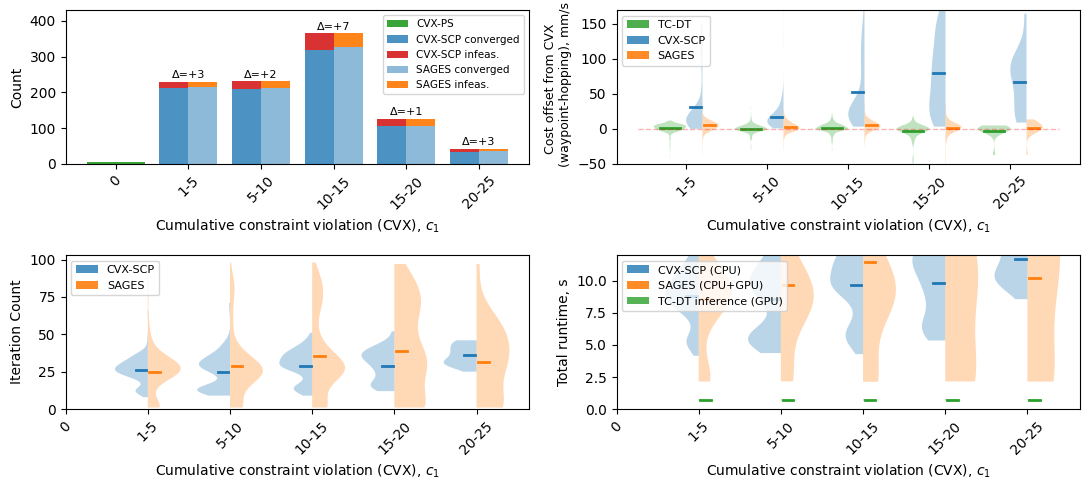

In [52]:
fig, (ax_stack, ax_cost, ax_iter, ax_runtime) = plot_cvx_art_summary(
    J_cvx, J_art, J_cvx_scp, J_art_scp,
    ctgs0_cvx,
    i_infeas_cvx, i_infeas_cvx_scp, i_infeas_art_scp,
    iter_cvx, iter_art,
    runtime_cvx_scp, runtime_DT_scp, runtime_DT,
)
fig.savefig("figures/ws_analysis_summary.png", dpi=600)

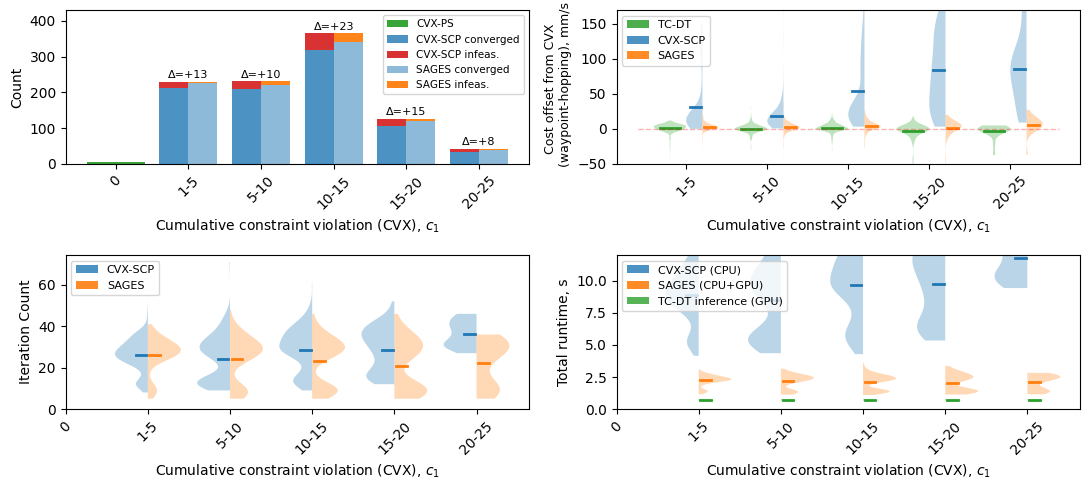

In [53]:
# compare against the reduced time grid (fixed) SCP 
fig, (ax_stack, ax_cost, ax_iter, ax_runtime) = plot_cvx_art_summary(
    J_cvx, J_art, J_cvx_scp, J_art_scp_r,
    ctgs0_cvx,
    i_infeas_cvx, i_infeas_cvx_scp, i_infeas_art_scp_r,
    iter_cvx, iter_art_r,
    runtime_cvx_scp, runtime_DT_scp_r, runtime_DT,
)

In [54]:
mask_feas = np.ones(len(runtime_DT_scp_r), dtype=bool)
mask_feas[i_infeas_art_scp_r] = False

runtime_DT_scp_r_feas = runtime_DT_scp_r[mask_feas]
max(runtime_DT_scp_r_feas)

3.6066293716430664

## inspect the semantic correspondence 

In [ ]:

eval_dict_DT = ws_data['eval_dict_DT']  
eval_dict_scp_cvx = ws_data['eval_dict_scp_cvx']    
eval_dict_scp_DT = ws_data['eval_dict_scp_DT']
eval_dict_scp_DT_fuel = ws_data['eval_dict_scp_DT_fuel']

In [ ]:
# summarize eval_dict_DT (warm-start, pre-SCP) 
for i in range(N_behavior):
    eval_dicts_i = eval_dict_DT[behav == i]
    all_keys = set().union(*eval_dicts_i)
    all_keys.discard("behavior")

    agg = {k: [] for k in all_keys}

    for d in eval_dicts_i:
        for k in all_keys:
            agg[k].append(d.get(k, None))
    
    # compute the mean / std for "d_roef" key 
    is_correct = np.array(agg['is_correct'])
    
    # print(f"\n=== Behavior {i} Summary ===")
    
    for k in all_keys:
        agg_k = np.array([np.array(v) for v in agg[k] if v is not None])
        agg[k] = agg_k
        
        # print(k)
        # if agg[k].dtype == np.bool_:
        #     print(agg_k) 
        # else: 
        #     print(np.round(agg_k, 2))

    print(f"Behavior {i}: correct rate (1) = {np.sum(is_correct[:,0])}/{len(is_correct[:,0])} = {np.sum(is_correct[:,0])/len(is_correct[:,0])*100:.2f}%")
    print(f"Behavior {i}: correct rate (2) = {np.sum(is_correct[:,1])}/{len(is_correct[:,1])} = {np.sum(is_correct[:,1])/len(is_correct[:,1])*100:.2f}%")
    print(f"Behavior {i}: correct rate (3) = {np.sum(is_correct[:,2])}/{len(is_correct[:,2])} = {np.sum(is_correct[:,2])/len(is_correct[:,2])*100:.2f}%")


In [ ]:
# summarize eval_dict_scp_cvx and eval_dict_scp_DT (post-SCP) 

for i in range(N_behavior):
    # --- baseline: DT results (same as you already do) ---
    eval_DT_i = eval_dict_DT[behav == i]          # all DT cases for this behavior
    n_DT_i = len(eval_DT_i)
    if n_DT_i == 0:
        print(f"Behavior {i}: no DT data, skipping.")
        continue

    all_keys = set().union(*eval_DT_i)
    all_keys.discard("behavior")

    agg = {k: [] for k in all_keys}
    for d in eval_DT_i:
        for k in all_keys:
            agg[k].append(d.get(k, None))

    is_correct_DT = np.array(agg["is_correct"])

    # --- 1) feasibility ratios for SCP-CVX and SCP-DT ---
    eval_scp_cvx_i = [d for d in eval_dict_scp_cvx if d.get("behavior") == i]
    eval_scp_DT_i  = [d for d in eval_dict_scp_DT  if d.get("behavior") == i]
    eval_scp_DT_fuel_i = [d for d in eval_dict_scp_DT_fuel  if d.get("behavior") == i]

    n_scpcvx_i = len(eval_scp_cvx_i)
    n_scpDT_i = len(eval_scp_DT_i)
    n_scpDTfuel_i = len(eval_scp_DT_fuel_i)

    feas_ratio_cvx   = n_scpcvx_i / n_DT_i
    feas_ratio_scpDT = n_scpDT_i / n_DT_i
    feas_ratio_scpDTfuel = n_scpDTfuel_i / n_DT_i
    
    print(f"\n=== Behavior {i} Summary ===")
    print(f"Feasibility (SCP-CVX) = {n_scpcvx_i}/{n_DT_i} = {feas_ratio_cvx * 100:.2f}%")
    print(f"Feasibility (SCP-DT)  = {n_scpDT_i}/{n_DT_i} = {feas_ratio_scpDT * 100:.2f}%")
    print(f"Feasibility (SCP-DT Fuel)  = {n_scpDTfuel_i}/{n_DT_i} = {feas_ratio_scpDTfuel * 100:.2f}%")

    # --- 2) overall success rates (correct & feasible, normalized by ALL DT cases) ---
    is_correct_scpcvx = np.array([d["is_correct"] for d in eval_scp_cvx_i], dtype=bool)
    n_scpcvx_correct1 = int(is_correct_scpcvx[:, 0].sum())
    n_scpcvx_correct2 = int(is_correct_scpcvx[:, 1].sum())
    n_scpcvx_correct3 = int(is_correct_scpcvx[:, 2].sum())

    is_correct_scpDT = np.array([d["is_correct"] for d in eval_scp_DT_i], dtype=bool)
    n_scpDT_correct1 = int(is_correct_scpDT[:, 0].sum())
    n_scpDT_correct2 = int(is_correct_scpDT[:, 1].sum())
    n_scpDT_correct3 = int(is_correct_scpDT[:, 2].sum())

    is_correct_scpDTfuel = np.array([d["is_correct"] for d in eval_scp_DT_fuel_i], dtype=bool)
    n_scpDTfuel_correct1 = int(is_correct_scpDTfuel[:, 0].sum())
    n_scpDTfuel_correct2 = int(is_correct_scpDTfuel[:, 1].sum())
    n_scpDTfuel_correct3 = int(is_correct_scpDTfuel[:, 2].sum())

    # IMPORTANT: divide by total DT count (n_DT_i), not only feasible ones
    success_ratio_scpcvx = n_scpcvx_correct1 / n_DT_i
    success_ratio_scpDT = n_scpDT_correct1 / n_DT_i
    success_ratio_scpDTfuel = n_scpDTfuel_correct1 / n_DT_i

    print(f"Overall success (SCP-CVX, q = 1) = {n_scpcvx_correct1}/{n_DT_i} = {n_scpcvx_correct1/n_DT_i * 100:.2f}%")
    print(f"Overall success (SCP-CVX, q = 2) = {n_scpcvx_correct2}/{n_DT_i} = {n_scpcvx_correct2/n_DT_i * 100:.2f}%")
    print(f"Overall success (SCP-CVX, q = 3) = {n_scpcvx_correct3}/{n_DT_i} = {n_scpcvx_correct3/n_DT_i * 100:.2f}%")
    print(f"Overall success (SCP-DT,  q = 1) = {n_scpDT_correct1}/{n_DT_i} = {n_scpDT_correct1/n_DT_i * 100:.2f}%")
    print(f"Overall success (SCP-DT,  q = 2) = {n_scpDT_correct2}/{n_DT_i} = {n_scpDT_correct2/n_DT_i * 100:.2f}%")
    print(f"Overall success (SCP-DT,  q = 3) = {n_scpDT_correct3}/{n_DT_i} = {n_scpDT_correct3/n_DT_i * 100:.2f}%")
    print(f"Overall success (SCP-DT Fuel,  q = 1) = {n_scpDTfuel_correct1}/{n_DT_i} = {n_scpDTfuel_correct1/n_DT_i * 100:.2f}%")
    print(f"Overall success (SCP-DT Fuel,  q = 2) = {n_scpDTfuel_correct2}/{n_DT_i} = {n_scpDTfuel_correct2/n_DT_i * 100:.2f}%")
    print(f"Overall success (SCP-DT Fuel,  q = 3) = {n_scpDTfuel_correct3}/{n_DT_i} = {n_scpDTfuel_correct3/n_DT_i * 100:.2f}%")
    


### 3D plot 

In [ ]:
# old version: need transpose
# roe_cvx = ws_data['roe_cvx'].transpose(0,2,1)  
# roe_art = ws_data['roe_DT'].transpose(0,2,1)
# roe_scp_cvx = ws_data['roe_scp_cvx'].transpose(0,2,1)
# roe_scp_DT = ws_data['roe_scp_DT'].transpose(0,2,1)
# rtn_cvx = ws_data['rtn_cvx'].transpose(0,2,1)
# rtn_art = ws_data['rtn_DT'].transpose(0,2,1)
# rtn_scp_cvx = ws_data['rtn_scp_cvx'].transpose(0,2,1)
# rtn_scp_DT = ws_data['rtn_scp_DT'].transpose(0,2,1)
# a_cvx = ws_data['a_cvx'].transpose(0,2,1)   
# a_art = ws_data['a_DT'].transpose(0,2,1)
# a_scp_cvx = ws_data['a_scp_cvx'].transpose(0,2,1)   
# a_scp_DT = ws_data['a_scp_DT'].transpose(0,2,1)
# oe = ws_data['oe'].transpose(0,2,1)

# new version: no transpose needed
roe_cvx = ws_data['roe_cvx']
roe_art = ws_data['roe_DT']
roe_scp_cvx = ws_data['roe_scp_cvx']
roe_scp_DT = ws_data['roe_scp_DT']
rtn_cvx = ws_data['rtn_cvx']   
rtn_art = ws_data['rtn_DT']
rtn_scp_cvx = ws_data['rtn_scp_cvx']
rtn_scp_DT = ws_data['rtn_scp_DT']
a_cvx = ws_data['a_cvx']   
a_art = ws_data['a_DT']
a_scp_cvx = ws_data['a_scp_cvx']   
a_scp_DT = ws_data['a_scp_DT']
oe = ws_data['oe']

In [ ]:
fig = plt.figure(figsize=(15,10))

phi = np.linspace(0, 2*np.pi, 50)  # tune this to get a better resolution
x_circ = dim_koz[0,1] * np.sin(phi) 
y_circ = dim_koz[0,2] * np.cos(phi)

x_proj = -90
y_proj = -200
z_proj = 80

for i in range(N_behavior): 
    print(f'Behavior mode {i}: {np.sum(behav==i)} samples')
    
    roe_cvx_i = roe_cvx[behav==i]
    roe_art_i = roe_art[behav==i]
    roe_scp_cvx_i = roe_scp_cvx[behav==i]
    roe_scp_DT_i = roe_scp_DT[behav==i]
    rtn_cvx_i = rtn_cvx[behav==i]
    rtn_art_i = rtn_art[behav==i]
    rtn_scp_cvx_i = rtn_scp_cvx[behav==i]
    rtn_scp_DT_i = rtn_scp_DT[behav==i]
    a_cvx_i   = a_cvx[behav==i]
    a_art_i   = a_art[behav==i]
    a_scp_cvx_i   = a_scp_cvx[behav==i] 
    a_scp_DT_i   = a_scp_DT[behav==i]
    oe_i = oe[behav==i]
    
    ax_i = fig.add_subplot(2, 3, i+1, projection='3d')
    ax_i.set_facecolor('white')
    ax_i.grid(False)
    for axis in [ax_i.xaxis, ax_i.yaxis, ax_i.zaxis]:
        axis.pane.fill = False
        axis.line.set_color('black')
        axis.line.set_linewidth(1)  # increase thickness

    for j in range(np.min([rtn_art_i.shape[0], 1])): 

        _, roe_cvx_ct_ij, rtn_cvx_ct_ij = propagate_ct(roe_cvx_i[j,:], a_cvx_i[j,:], oe_i[j,:], tvec_sec, n=10)
        _, roe_art_ct_ij, rtn_art_ct_ij = propagate_ct(roe_art_i[j,:], a_art_i[j,:], oe_i[j,:], tvec_sec, n=10)
        _, roe_scp_cvx_ct_ij, rtn_scp_cvx_ct_ij = propagate_ct(roe_scp_cvx_i[j,:], a_cvx_i[j,:], oe_i[j,:], tvec_sec, n=10)
        _, roe_scp_DT_ct_ij, rtn_scp_DT_ct_ij = propagate_ct(roe_scp_DT_i[j,:], a_scp_DT_i[j,:], oe_i[j,:], tvec_sec, n=10)
        _, roe_scp_cvx_ct_ij, rtn_scp_cvx_ct_ij = propagate_ct(roe_scp_cvx_i[j,:], a_scp_cvx_i[j,:], oe_i[j,:], tvec_sec, n=10)

        x_cvx, y_cvx, z_cvx = rtn_cvx_ct_ij[:,0], rtn_cvx_ct_ij[:,1], rtn_cvx_ct_ij[:,2]
        x_art, y_art, z_art = rtn_art_ct_ij[:,0], rtn_art_ct_ij[:,1], rtn_art_ct_ij[:,2]
        x_scp_cvx, y_scp_cvx, z_scp_cvx = rtn_scp_cvx_ct_ij[:,0], rtn_scp_cvx_ct_ij[:,1], rtn_scp_cvx_ct_ij[:,2]
        x_scp_DT, y_scp_DT, z_scp_DT = rtn_scp_DT_ct_ij[:,0], rtn_scp_DT_ct_ij[:,1], rtn_scp_DT_ct_ij[:,2]

        # plot trajectories
        ax_i.plot(y_cvx, z_cvx, x_cvx, 'b--', linewidth=1, zorder=5)
        ax_i.plot(y_art, z_art, x_art, 'g-', linewidth=1, zorder=5)
        ax_i.plot(y_scp_cvx, z_scp_cvx, x_scp_cvx, 'm-.', linewidth=1, zorder=5)
        ax_i.plot(y_scp_DT, z_scp_DT, x_scp_DT, 'c:', linewidth=1, zorder=5)

        # minimal "projection shadows" onto planes
        alpha = 0.7
        ax_i.plot(y_art, z_art, np.full_like(x_art, x_proj), 'k-', alpha=alpha, linewidth=0.5)  # xy plane (RT)
        ax_i.plot(y_art, np.full_like(z_art, z_proj), x_art, 'k-', alpha=alpha, linewidth=0.5)  # xz plane (RN)
        ax_i.plot(np.full_like(y_art, y_proj), z_art, x_art, 'k-', alpha=alpha, linewidth=0.5)  # yz plane (TN)

        ax_i.scatter([y_cvx[0]], [z_cvx[0]], [x_cvx[0]], c='red', marker='o', s=20, zorder=10)
        ax_i.scatter([y_cvx[-1]], [z_cvx[-1]], [x_cvx[-1]], c='orange', marker='o', s=20, zorder=10)

    plot_ellipse(ax_i, np.array([dim_koz[0,1], dim_koz[0,2], dim_koz[0,0]]), pos=[0,0,0], Ndisc=20)
    ax_i.scatter([0], [0], [0], c='red', marker='o', s=8)

    # circle (kOZ) projection
    ax_i.plot(y_circ, x_circ, np.full_like(x_circ, x_proj), 'r-', alpha=alpha, linewidth=0.5)
    ax_i.plot(x_circ, np.full_like(x_circ, z_proj), y_circ, 'r-', alpha=alpha, linewidth=0.5)
    ax_i.plot(np.full_like(x_circ, y_proj), y_circ, x_circ, 'r-', alpha=alpha, linewidth=0.5)

    ax_i.set_title(f'Behavior: {i}')
    ax_i.set_xlabel('T [m]')
    ax_i.set_ylabel('N [m]')
    ax_i.set_zlabel('R [m]')
    # ax_i.set_box_aspect([1,1,1])
    
    if i == 0: 
        ax_i.plot([],[], 'b--', label='trajectory (CVX)')
        ax_i.plot([],[], 'g-', label='trajectory (ART)')
        ax_i.scatter([],[], c='red', marker='o', label='Start')
        ax_i.scatter([],[], c='orange', marker='o', label='Goal')
        ax_i.legend()

fig.tight_layout()

In [ ]:
# --- figure + layout -------------------------------------------------
fig = plt.figure(figsize=(11, 6))  # ~4:3 aspect overall

# ratio of top-row height to bottom-row height (tune this)
top_to_bottom = 3.0
gs = fig.add_gridspec(
    3, 3,
    width_ratios=[1.0, 3, 1.3]  # top row taller
)

# 3D RTN trajectory: spans the entire top row
ax_i = fig.add_subplot(gs[:, 1], projection='3d')

# three ROE subplots: bottom row
axi1 = fig.add_subplot(gs[0, 0])
axi2 = fig.add_subplot(gs[1, 0])
axi3 = fig.add_subplot(gs[2, 0])

axu1 = fig.add_subplot(gs[0, 2])
axu2 = fig.add_subplot(gs[1, 2])
axu3 = fig.add_subplot(gs[2, 2])

phi = np.linspace(0, 2*np.pi, 50)  # tune this to get a better resolution
x_circ = dim_koz[0,1] * np.sin(phi) 
y_circ = dim_koz[0,2] * np.cos(phi)

x_proj = -90
y_proj = -200
z_proj = 80

sage = "limegreen" #"#87ae83"
darkyellow = "#BA8E23"
skyblue = "lightskyblue"
c_tcdt = "darkgreen"

i = 0 
print(f'Behavior mode {i}: {np.sum(behav==i)} samples')

roe_cvx_i = roe_cvx[behav==i]
roe_art_i = roe_art[behav==i]
roe_scp_cvx_i = roe_scp_cvx[behav==i]
roe_scp_DT_i = roe_scp_DT[behav==i]
rtn_cvx_i = rtn_cvx[behav==i]
rtn_art_i = rtn_art[behav==i]
rtn_scp_cvx_i = rtn_scp_cvx[behav==i]
rtn_scp_DT_i = rtn_scp_DT[behav==i]
a_cvx_i   = a_cvx[behav==i]
a_art_i   = a_art[behav==i]
a_scp_cvx_i   = a_scp_cvx[behav==i] 
a_scp_DT_i   = a_scp_DT[behav==i]
oe_i = oe[behav==i]

# ----- 3D RTN plot (top row) -----------------------------------------
ax_i.set_facecolor('white')
ax_i.grid(False)
for axis in [ax_i.xaxis, ax_i.yaxis, ax_i.zaxis]:
    axis.pane.fill = False
    axis.line.set_color('black')
    axis.line.set_linewidth(1)  # increase thickness

for j in range(np.min([rtn_art_i.shape[0], 1])): 

    _, roe_cvx_ct_ij, rtn_cvx_ct_ij = propagate_ct(roe_cvx_i[j,:], a_cvx_i[j,:], oe_i[j,:], tvec_sec, n=10)
    _, roe_art_ct_ij, rtn_art_ct_ij = propagate_ct(roe_art_i[j,:], a_art_i[j,:], oe_i[j,:], tvec_sec, n=10)
    _, roe_scp_cvx_ct_ij, rtn_scp_cvx_ct_ij = propagate_ct(roe_scp_cvx_i[j,:], a_cvx_i[j,:], oe_i[j,:], tvec_sec, n=10)
    _, roe_scp_DT_ct_ij, rtn_scp_DT_ct_ij = propagate_ct(roe_scp_DT_i[j,:], a_scp_DT_i[j,:], oe_i[j,:], tvec_sec, n=10)
    _, roe_scp_cvx_ct_ij, rtn_scp_cvx_ct_ij = propagate_ct(roe_scp_cvx_i[j,:], a_scp_cvx_i[j,:], oe_i[j,:], tvec_sec, n=10)
    x_cvx, y_cvx, z_cvx = rtn_cvx_ct_ij[:,0], rtn_cvx_ct_ij[:,1], rtn_cvx_ct_ij[:,2]
    x_art, y_art, z_art = rtn_art_ct_ij[:,0], rtn_art_ct_ij[:,1], rtn_art_ct_ij[:,2]
    x_scp_cvx, y_scp_cvx, z_scp_cvx = rtn_scp_cvx_ct_ij[:,0], rtn_scp_cvx_ct_ij[:,1], rtn_scp_cvx_ct_ij[:,2]
    x_scp_DT, y_scp_DT, z_scp_DT = rtn_scp_DT_ct_ij[:,0], rtn_scp_DT_ct_ij[:,1], rtn_scp_DT_ct_ij[:,2]

    # plot trajectories
    ax_i.plot(y_scp_cvx, z_scp_cvx, x_scp_cvx, linestyle='-', c=skyblue, linewidth=1, zorder=5)
    ax_i.plot(y_scp_DT, z_scp_DT, x_scp_DT, linestyle="-",  c=sage, linewidth=1, zorder=5)
    ax_i.plot(y_cvx, z_cvx, x_cvx, 'b--', linewidth=1, zorder=5)
    ax_i.plot(y_art, z_art, x_art, '--', c=c_tcdt, linewidth=1, zorder=5)

    # minimal "projection shadows" onto planes
    alpha = 0.7
    ax_i.plot(y_art, z_art, np.full_like(x_art, x_proj), 'k-', alpha=alpha, linewidth=0.5)  # xy plane (RT)
    ax_i.plot(y_art, np.full_like(z_art, z_proj), x_art, 'k-', alpha=alpha, linewidth=0.5)  # xz plane (RN)
    ax_i.plot(np.full_like(y_art, y_proj), z_art, x_art, 'k-', alpha=alpha, linewidth=0.5)  # yz plane (TN)

    ax_i.scatter([y_cvx[0]], [z_cvx[0]], [x_cvx[0]], c='red', marker='o', s=20, zorder=10)
    ax_i.scatter([y_cvx[-1]], [z_cvx[-1]], [x_cvx[-1]], c='orange', marker='o', s=20, zorder=10)

plot_ellipse(ax_i, np.array([dim_koz[0,1], dim_koz[0,2], dim_koz[0,0]]), pos=[0,0,0], Ndisc=20)

# circle (KOZ) projection
ax_i.plot(y_circ, x_circ, np.full_like(x_circ, x_proj), 'r-', alpha=alpha, linewidth=0.5)
ax_i.plot(x_circ, np.full_like(x_circ, z_proj), y_circ, 'r-', alpha=alpha, linewidth=0.5)
ax_i.plot(np.full_like(x_circ, y_proj), y_circ, x_circ, 'r-', alpha=alpha, linewidth=0.5)

ax_i.set_xlabel('$T$, m')
ax_i.set_ylabel('$N$, m')
ax_i.set_zlabel('$R$, m')
# ax_i.set_box_aspect([1, 1, 1])  # optional: enforce cube-like aspect

# ----- ROE plots (bottom row) ----------------------------------------
j = 0

axi1.plot(roe_scp_cvx_i[j,:,1], roe_scp_cvx_i[j,:,0], c=skyblue, linestyle='-', linewidth=1.5) 
axi2.plot(roe_scp_cvx_i[j,:,2], roe_scp_cvx_i[j,:,3], c=skyblue, linestyle='-', linewidth=1.5)
axi3.plot(roe_scp_cvx_i[j,:,4], roe_scp_cvx_i[j,:,5], c=skyblue, linestyle='-', linewidth=1.5)

axi1.plot(roe_scp_DT_i[j,:,1], roe_scp_DT_i[j,:,0], linestyle = '-', c=sage, linewidth=1.5)
axi2.plot(roe_scp_DT_i[j,:,2], roe_scp_DT_i[j,:,3], linestyle = '-', c=sage, linewidth=1.5)
axi3.plot(roe_scp_DT_i[j,:,4], roe_scp_DT_i[j,:,5], linestyle = '-', c=sage, linewidth=1.5)

axi1.plot(roe_art_i[j,:,1], roe_art_i[j,:,0], '--', c=c_tcdt, linewidth=1.5)
axi2.plot(roe_art_i[j,:,2], roe_art_i[j,:,3], '--', c=c_tcdt, linewidth=1.5)
axi3.plot(roe_art_i[j,:,4], roe_art_i[j,:,5], '--', c=c_tcdt, linewidth=1.5)

axi1.plot(roe_cvx_i[j,:,1], roe_cvx_i[j,:,0], 'b--', linewidth=1.5)
axi2.plot(roe_cvx_i[j,:,2], roe_cvx_i[j,:,3], 'b--', linewidth=1.5)
axi3.plot(roe_cvx_i[j,:,4], roe_cvx_i[j,:,5], 'b--', linewidth=1.5)

s = 20 
axi1.scatter([roe_art_i[j,0,1]],  [roe_art_i[j,0,0]],  c='red',    marker='o', s=s, zorder=5)
axi1.scatter([roe_art_i[j,-1,1]], [roe_art_i[j,-1,0]], c='orange', marker='o', s=s, zorder=5)
axi2.scatter([roe_art_i[j,0,2]],  [roe_art_i[j,0,3]],  c='red',    marker='o', s=s, zorder=5)
axi2.scatter([roe_art_i[j,-1,2]], [roe_art_i[j,-1,3]], c='orange', marker='o', s=s, zorder=5)
axi3.scatter([roe_art_i[j,0,4]],  [roe_art_i[j,0,5]],  c='red',    marker='o', s=s, zorder=5)
axi3.scatter([roe_art_i[j,-1,4]], [roe_art_i[j,-1,5]], c='orange', marker='o', s=s, zorder=5)
    
print("initial ROE:", roe_art_i[j,0,:])

ax_i.plot([],[], 'b--', label='CVX')
ax_i.plot([],[], c=skyblue, linestyle='-', label='SCP-CVX')
ax_i.plot([],[], '--', c=c_tcdt, label='TC-DT')
ax_i.plot([],[], '-', c=sage, label='SAGES')
ax_i.scatter([],[], c='red',    marker='o', label='Start')
ax_i.scatter([],[], c='orange', marker='o', label='Goal')
ax_i.legend(ncol=3, fontsize=10, loc='best')

axi1.grid(True); axi2.grid(True); axi3.grid(True)

axi1.set_xlabel('$a \delta \lambda$, m')
axi1.set_ylabel('$a \delta a$, m')
axi2.set_xlabel('$a \delta e_x$, m')
axi2.set_ylabel('$a \delta e_y$, m')
axi3.set_xlabel('$a \delta i_x$, m')
axi3.set_ylabel('$a \delta i_y$, m')

### Control inputs plots ###########
axu1.grid(True); axu2.grid(True); axu3.grid(True)
axu1.set_ylabel('$\Delta V_R$, mm/s')
axu2.set_ylabel('$\Delta V_T$, mm/s')
axu3.set_ylabel('$\Delta V_N$, mm/s')
axu1.set_ylim([-21, 21]); axu2.set_ylim([-21, 21]); axu3.set_ylim([-21, 21])
axu1.set_xlim([-0.1, 5.1]); axu2.set_xlim([-0.1, 5.1]); axu3.set_xlim([-0.1, 5.1])
axu1.set_xlabel('Time, orbit')
axu2.set_xlabel('Time, orbit')
axu3.set_xlabel('Time, orbit')

for ax in [axu1, axu2, axu3]:
    ax.set_xticks([0,1,2,3,4, 5])

eps = 1  # threshold for "near zero"
def stem_nonzero(ax, t, u, color, markerfmt='o', scale=1.0):
    u_plot = u * scale
    mask = np.abs(u_plot) > eps

    markerline, stemlines, baseline = ax.stem(
        t[mask], u_plot[mask], markerfmt=markerfmt
    )
    markerline.set_color(color)
    stemlines.set_color(color)
    baseline.set_color(color)
    return markerline, stemlines, baseline

stem_nonzero(axu1, tvec_sec/period, a_scp_DT_i[j,:,0], sage, scale=1e3)
stem_nonzero(axu2, tvec_sec/period, a_scp_DT_i[j,:,1], sage, scale=1e3)
stem_nonzero(axu3, tvec_sec/period, a_scp_DT_i[j,:,2], sage, scale=1e3)

stem_nonzero(axu1, tvec_sec/period, a_scp_cvx_i[j,:,0], skyblue, markerfmt='d', scale=1e3)
stem_nonzero(axu2, tvec_sec/period, a_scp_cvx_i[j,:,1], skyblue, markerfmt='d', scale=1e3)
stem_nonzero(axu3, tvec_sec/period, a_scp_cvx_i[j,:,2], skyblue, markerfmt='d', scale=1e3)

fig.tight_layout()
dx = 0.1
pos = ax_i.get_position()
ax_i.set_position([pos.x0 - dx, pos.y0, pos.width + dx, pos.height])
pos = ax_i.get_position()
shrink = 0.03   # amount to reduce margins on all sides
ax_i.set_position([
    pos.x0 - shrink,      # move left edge right → reduces left margin
    pos.y0 - 2 * shrink ,    # move bottom edge up → reduces bottom margin
    pos.width + 2*shrink, # shrink width
    pos.height + 2*shrink # shrink height
])
fig.savefig("figures/ws_analysis_roe_traj.png", dpi=600, bbox_inches='tight', pad_inches=0.5)


In [ ]:
# only the first one 
fig = plt.figure(figsize=(8,8))

phi = np.linspace(0, 2*np.pi, 50)  # tune this to get a better resolution
x_circ = dim_koz[0,1] * np.sin(phi) 
y_circ = dim_koz[0,2] * np.cos(phi)

x_proj = -90
y_proj = -200
z_proj = 80

sage = "lime" #"#87ae83"
darkyellow = "#BA8E23"

i = 0 
print(f'Behavior mode {i}: {np.sum(behav==i)} samples')

roe_cvx_i = roe_cvx[behav==i]
roe_art_i = roe_art[behav==i]
roe_scp_cvx_i = roe_scp_cvx[behav==i]
roe_scp_DT_i = roe_scp_DT[behav==i]
rtn_cvx_i = rtn_cvx[behav==i]
rtn_art_i = rtn_art[behav==i]
rtn_scp_cvx_i = rtn_scp_cvx[behav==i]
rtn_scp_DT_i = rtn_scp_DT[behav==i]
a_cvx_i   = a_cvx[behav==i]
a_art_i   = a_art[behav==i]
a_scp_cvx_i   = a_scp_cvx[behav==i] 
a_scp_DT_i   = a_scp_DT[behav==i]
oe_i = oe[behav==i]

ax_i = fig.add_subplot(2, 2, 2, projection='3d')
ax_i.set_facecolor('white')
ax_i.grid(False)
for axis in [ax_i.xaxis, ax_i.yaxis, ax_i.zaxis]:
    axis.pane.fill = False
    axis.line.set_color('black')
    axis.line.set_linewidth(1)  # increase thickness

for j in range(np.min([rtn_art_i.shape[0], 1])): 

    _, roe_cvx_ct_ij, rtn_cvx_ct_ij = propagate_ct(roe_cvx_i[j,:].T, a_cvx_i[j,:].T, oe_i[j,:].T, tvec_sec, n=10)
    _, roe_art_ct_ij, rtn_art_ct_ij = propagate_ct(roe_art_i[j,:].T, a_art_i[j,:].T, oe_i[j,:].T, tvec_sec, n=10)
    _, roe_scp_cvx_ct_ij, rtn_scp_cvx_ct_ij = propagate_ct(roe_scp_cvx_i[j,:].T, a_cvx_i[j,:].T, oe_i[j,:].T, tvec_sec, n=10)
    _, roe_scp_DT_ct_ij, rtn_scp_DT_ct_ij = propagate_ct(roe_scp_DT_i[j,:].T, a_scp_DT_i[j,:].T, oe_i[j,:].T, tvec_sec, n=10)
    _, roe_scp_cvx_ct_ij, rtn_scp_cvx_ct_ij = propagate_ct(roe_scp_cvx_i[j,:].T, a_scp_cvx_i[j,:].T, oe_i[j,:].T, tvec_sec, n=10)

    x_cvx, y_cvx, z_cvx = rtn_cvx_ct_ij[0], rtn_cvx_ct_ij[1], rtn_cvx_ct_ij[2]
    x_art, y_art, z_art = rtn_art_ct_ij[0], rtn_art_ct_ij[1], rtn_art_ct_ij[2]
    x_scp_cvx, y_scp_cvx, z_scp_cvx = rtn_scp_cvx_ct_ij[0], rtn_scp_cvx_ct_ij[1], rtn_scp_cvx_ct_ij[2]
    x_scp_DT, y_scp_DT, z_scp_DT = rtn_scp_DT_ct_ij[0], rtn_scp_DT_ct_ij[1], rtn_scp_DT_ct_ij[2]

    # plot trajectories
    ax_i.plot(y_cvx, z_cvx, x_cvx, 'b--', linewidth=1, zorder=5)
    ax_i.plot(y_art, z_art, x_art, 'm-.', linewidth=1, zorder=5)
    ax_i.plot(y_scp_cvx, z_scp_cvx, x_scp_cvx, 'g-', linewidth=1, zorder=5)
    ax_i.plot(y_scp_DT, z_scp_DT, x_scp_DT, c=sage, linewidth=1, zorder=5)

    # minimal "projection shadows" onto planes
    alpha = 0.7
    ax_i.plot(y_art, z_art, np.full_like(x_art, x_proj), 'k-', alpha=alpha, linewidth=0.5)  # xy plane (RT)
    ax_i.plot(y_art, np.full_like(z_art, z_proj), x_art, 'k-', alpha=alpha, linewidth=0.5)  # xz plane (RN)
    ax_i.plot(np.full_like(y_art, y_proj), z_art, x_art, 'k-', alpha=alpha, linewidth=0.5)  # yz plane (TN)

    ax_i.scatter([y_cvx[0]], [z_cvx[0]], [x_cvx[0]], c='red', marker='o', s=20, zorder=10)
    ax_i.scatter([y_cvx[-1]], [z_cvx[-1]], [x_cvx[-1]], c='orange', marker='o', s=20, zorder=10)

plot_ellipse(ax_i, np.array([dim_koz[0,1], dim_koz[0,2], dim_koz[0,0]]), pos=[0,0,0], Ndisc=20)

# circle (kOZ) projection
ax_i.plot(y_circ, x_circ, np.full_like(x_circ, x_proj), 'r-', alpha=alpha, linewidth=0.5)
ax_i.plot(x_circ, np.full_like(x_circ, z_proj), y_circ, 'r-', alpha=alpha, linewidth=0.5)
ax_i.plot(np.full_like(x_circ, y_proj), y_circ, x_circ, 'r-', alpha=alpha, linewidth=0.5)

ax_i.set_xlabel('$T$, m')
ax_i.set_ylabel('$N$, m')
ax_i.set_zlabel('$R$, m')
# ax_i.axis('equal')
# ax_i.set_box_aspect([1,1,1])

# ax_i.plot([],[], 'b--', label='trajectory (CVX)')
# ax_i.plot([],[], 'g-', label='trajectory (ART)')
# ax_i.scatter([],[], c='red', marker='o', label='Start')
# ax_i.scatter([],[], c='orange', marker='o', label='Goal')
# ax_i.legend()

### ROE PLOT ###########

axi1 = fig.add_subplot(2, 2, 1)
axi2 = fig.add_subplot(2, 2, 3)
axi3 = fig.add_subplot(2, 2, 4)

for j in range(np.min([roe_art_i.shape[0], 1])):
    axi1.plot(roe_art_i[j,:,1], roe_art_i[j,:,0], 'm-.', linewidth=1.5)
    axi2.plot(roe_art_i[j,:,2], roe_art_i[j,:,3], 'm-.', linewidth=1.5)
    axi3.plot(roe_art_i[j,:,4], roe_art_i[j,:,5], 'm-.', linewidth=1.5)

    axi1.plot(roe_cvx_i[j,:,1], roe_cvx_i[j,:,0], 'b--', linewidth=1.5)
    axi2.plot(roe_cvx_i[j,:,2], roe_cvx_i[j,:,3], 'b--', linewidth=1.5)
    axi3.plot(roe_cvx_i[j,:,4], roe_cvx_i[j,:,5], 'b--', linewidth=1.5)
    
    axi1.plot(roe_scp_cvx_i[j,:,1], roe_scp_cvx_i[j,:,0], 'g-', linewidth=1.5) 
    axi2.plot(roe_scp_cvx_i[j,:,2], roe_scp_cvx_i[j,:,3], 'g-', linewidth=1.5)
    axi3.plot(roe_scp_cvx_i[j,:,4], roe_scp_cvx_i[j,:,5], 'g-', linewidth=1.5)
    
    axi1.plot(roe_scp_DT_i[j,:,1], roe_scp_DT_i[j,:,0], c=sage, linewidth=1.5)
    axi2.plot(roe_scp_DT_i[j,:,2], roe_scp_DT_i[j,:,3], c=sage, linewidth=1.5)
    axi3.plot(roe_scp_DT_i[j,:,4], roe_scp_DT_i[j,:,5], c=sage, linewidth=1.5)
    

    s = 20 
    axi1.scatter([roe_art_i[j,0,1]], [roe_art_i[j,0,0]], c='red', marker='o', s=s, zorder=5)
    axi1.scatter([roe_art_i[j,-1,1]], [roe_art_i[j,-1,0]], c='orange', marker='o', s=s, zorder=5)
    axi2.scatter([roe_art_i[j,0,2]], [roe_art_i[j,0,3]], c='red', marker='o', s=s, zorder=5)
    axi2.scatter([roe_art_i[j,-1,2]], [roe_art_i[j,-1,3]], c='orange', marker='o', s=s, zorder=5)
    axi3.scatter([roe_art_i[j,0,4]], [roe_art_i[j,0,5]], c='red', marker='o', s=s, zorder=5)
    axi3.scatter([roe_art_i[j,-1,4]], [roe_art_i[j,-1,5]], c='orange', marker='o', s=s, zorder=5)
    

    axi1.plot([],[], 'b--', label='CVX')
    axi1.plot([],[], 'g-', label='SCP-CVX')
    axi1.plot([],[], 'm-.', label='TC-DT')
    axi1.plot([],[], '-', c=sage, label='SAGES')
    axi1.scatter([],[], c='red', marker='o', label='Start')
    axi1.scatter([],[], c='orange', marker='o', label='Goal')
    axi1.legend(fontsize=10, loc='lower left')

# axi2.set_xlim([-55, 55]) 
# axi2.set_ylim([-55, 55]) 
# axi3.set_xlim([-55, 55])
# axi3.set_ylim([-55, 55])
axi1.grid(True); axi2.grid(True); axi3.grid(True)
# axi2.axis('equal')
# axi3.axis('equal')

axi1.set_xlabel('$a \delta \lambda$, m')
axi1.set_ylabel('$a \delta a$, m')
axi2.set_xlabel('$a \delta e_x$, m')
axi2.set_ylabel('$a \delta e_y$, m')
axi3.set_xlabel('$a \delta i_x$, m')
axi3.set_ylabel('$a \delta i_y$, m')

# fig.tight_layout()
fig.savefig("figures/ws_analysis_roe_traj.png", dpi=600, bbox_inches='tight', pad_inches=0.5)

In [ ]:
fs = 9

# ROE plot 
fig = plt.figure(figsize=(15,6))
for i in range(N_behavior):

    roe_cvx_i = roe_cvx[behav==i] 
    roe_art_i = roe_art[behav==i]   # convert to mm/s^2
    roe_scp_cvx_i = roe_scp_cvx[behav==i]
    roe_scp_DT_i = roe_scp_DT[behav==i]

    axi1 = fig.add_subplot(3, N_behavior, i+1)
    axi2 = fig.add_subplot(3, N_behavior, i+1+N_behavior)
    axi3 = fig.add_subplot(3, N_behavior, i+1+N_behavior*2)
    
    for j in range(np.min([roe_art_i.shape[0], 1])):
        axi1.plot(roe_art_i[j,:,1], roe_art_i[j,:,0], 'g-', linewidth=1.5)
        axi2.plot(roe_art_i[j,:,2], roe_art_i[j,:,3], 'g-', linewidth=1.5)
        axi3.plot(roe_art_i[j,:,4], roe_art_i[j,:,5], 'g-', linewidth=1.5)

        axi1.plot(roe_cvx_i[j,:,1], roe_cvx_i[j,:,0], 'b-', linewidth=1.5)
        axi2.plot(roe_cvx_i[j,:,2], roe_cvx_i[j,:,3], 'b-', linewidth=1.5)
        axi3.plot(roe_cvx_i[j,:,4], roe_cvx_i[j,:,5], 'b-', linewidth=1.5)
        
        axi1.plot(roe_scp_cvx_i[j,:,1], roe_scp_cvx_i[j,:,0], 'm-.', linewidth=1.5) 
        axi2.plot(roe_scp_cvx_i[j,:,2], roe_scp_cvx_i[j,:,3], 'm-.', linewidth=1.5)
        axi3.plot(roe_scp_cvx_i[j,:,4], roe_scp_cvx_i[j,:,5], 'm-.', linewidth=1.5)
        
        axi1.plot(roe_scp_DT_i[j,:,1], roe_scp_DT_i[j,:,0], 'c:', linewidth=1.5)
        axi2.plot(roe_scp_DT_i[j,:,2], roe_scp_DT_i[j,:,3], 'c:', linewidth=1.5)
        axi3.plot(roe_scp_DT_i[j,:,4], roe_scp_DT_i[j,:,5], 'c:', linewidth=1.5)
        

        axi1.scatter([roe_art_i[j,0,1]], [roe_art_i[j,0,0]], c='red', marker='o', s=5, zorder=5)
        axi1.scatter([roe_art_i[j,-1,1]], [roe_art_i[j,-1,0]], c='orange', marker='o', s=5, zorder=5)
        axi2.scatter([roe_art_i[j,0,2]], [roe_art_i[j,0,3]], c='red', marker='o', s=5, zorder=5)
        axi2.scatter([roe_art_i[j,-1,2]], [roe_art_i[j,-1,3]], c='orange', marker='o', s=5, zorder=5)
        axi3.scatter([roe_art_i[j,0,4]], [roe_art_i[j,0,5]], c='red', marker='o', s=5, zorder=5)
        axi3.scatter([roe_art_i[j,-1,4]], [roe_art_i[j,-1,5]], c='orange', marker='o', s=5, zorder=5)
        

        if i == 0 and j == 0:
            axi2.plot([],[], 'b-', label='roe (cvx)')
            axi2.plot([],[], 'g-', label='roe (art)')
            axi2.scatter([],[], c='red', marker='o', label='Start')
            axi2.scatter([],[], c='orange', marker='o', label='Goal')
            axi2.legend(fontsize=fs, loc='upper left')
    
    axi2.set_xlim([-55, 55]) 
    axi2.set_ylim([-55, 55]) 
    axi3.set_xlim([-55, 55])
    axi3.set_ylim([-55, 55])
    axi1.grid(True); axi2.grid(True); axi3.grid(True)
    # axi2.axis('equal')
    # axi3.axis('equal')

    axi1.set_xlabel('$a \delta \lambda$ [m]')
    axi1.set_ylabel('$a \delta a$ [m]')
    axi2.set_xlabel('$a \delta e_x$ [m]')
    axi2.set_ylabel('$a \delta e_y$ [m]')
    axi3.set_xlabel('$a \delta i_x$ [m]')
    axi3.set_ylabel('$a \delta i_y$ [m]')
    axi1.set_title(f'Behavior: {i}')
    
plt.tight_layout()


In [ ]:
# control history 
control = False
if control: 
    fig = plt.figure(figsize=(12,4))
    for i in range(N_behavior):
        
        a_cvx_i = a_cvx[behav==i] * 1000
        a_art_i = a_art[behav==i] * 1000  # convert to mm/s^2

        axi1 = fig.add_subplot(3, N_behavior, i+1)
        axi3 = fig.add_subplot(3, N_behavior, i+1+N_behavior*2)
        
        axi2 = fig.add_subplot(3, N_behavior, i+1+N_behavior)
        for j in range(np.min([a_art_i.shape[0], 1])):
            axi1.plot(a_art_i[j,:,0], 'g-', linewidth=1)
            axi2.plot(a_art_i[j,:,1], 'g-', linewidth=1)
            axi3.plot(a_art_i[j,:,2], 'g-', linewidth=1)

            axi1.plot(a_cvx_i[j,:,0], 'b-', linewidth=1)
            axi2.plot(a_cvx_i[j,:,1], 'b-', linewidth=1)
            axi3.plot(a_cvx_i[j,:,2], 'b-', linewidth=1)
            
            if i == 0 and j == 0:
                axi1.plot([],[], 'b-', label='a_cvx')
                axi1.plot([],[], 'g-', label='a_art')
                axi1.legend()
        
        if i == 0:
            axi1.set_ylabel('$\Delta V_R$ [mm/s]')
            axi2.set_ylabel('$\Delta V_T$ [mm/s]')
            axi3.set_ylabel('$\Delta V_N$ [mm/s]')
        
        axi3.set_xlabel('Time step')
        axi1.set_title(f'Behavior: {i}')
        
    plt.tight_layout()
        